In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

try:
    master_df = pd.read_csv('/content/drive/MyDrive/master_df.csv')
    print('Successfully read master_df.csv')
    display(master_df)
except FileNotFoundError:
    print('File not found. Please check the path in Google Drive.')

Mounted at /content/drive
Successfully read master_df.csv


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_status,order_year,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,total_order_value,delivery_delay_days,is_late_delivery,high_value_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,38.71,-8.0,0,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,38.71,-8.0,0,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,38.71,-8.0,0,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Delivered,2018,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,141.46,-6.0,0,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Delivered,2018,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18 00:00:00,2018-08-22 19:07:58,179.12,-18.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Delivered,2018,...,29bb71b2760d0f876dfa178a76bc4734,4.0,No Title,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,195.00,-2.0,0,0
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Delivered,2017,...,371579771219f6db2d830d50805977bb,5.0,No Title,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,271.01,-6.0,0,0
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Delivered,2018,...,8ab6855b9fe9b812cd03a480a25058a1,2.0,No Title,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,220.58,-21.0,0,0
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Delivered,2018,...,8ab6855b9fe9b812cd03a480a25058a1,2.0,No Title,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,220.58,-21.0,0,0


---
# MODEL 1 — Rule-Based Recommendation Engine

**Logic:** For a given customer:
1. Find their favourite categories (what they buy most)
2. Find their usual price range (avg spend ± 30%)
3. Filter products matching both, rated >= 4.0
4. If not enough results → fallback to top sellers in their state
5. Rank by score: 60% rating + 40% popularity

In [5]:
# Build product catalogue — one row per product with stats

catalogue = (
    master_df.groupby(['product_id', 'product_category_name_english'])
    .agg(
        avg_price    = ('price',        'mean'),
        avg_rating   = ('review_score', 'mean'),
        total_orders = ('order_id',     'count')
    )
    .reset_index()
)

print('Products in catalogue:', len(catalogue))
catalogue

Products in catalogue: 32951


,product_id,product_category_name_english,avg_price,avg_rating,total_orders
0,00066f42aeeb9f3007548bb9d3f33c38,perfumery,101.65,5.0,1
1,00088930e925c41fd95ebfe695fd2655,auto,129.90,4.0,1
2,0009406fd7479715e4bef61dd91f2462,bed_bath_table,229.00,1.0,1
3,000b8f95fcb9e0096488278317764d19,housewares,58.90,5.0,2
4,000d9be29b5207b54e86aa1b1ac54872,watches_gifts,199.00,5.0,1
...,...,...,...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,cool_stuff,114.99,4.5,2
32947,fff81cc3158d2725c0655ab9ba0f712c,health_beauty,90.00,4.0,1
32948,fff9553ac224cec9d15d49f5a263411f,fashion_bags_accessories,32.00,5.0,1
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,computers_accessories,33.99,5.0,5


In [6]:
# Build customer profiles

customer_profiles = (
    master_df.groupby('customer_unique_id')
    .agg(
        fav_categories = ('product_category_name_english',
                          lambda x: x.value_counts().index[:3].tolist()),
        avg_spend      = ('price',          'mean'),
        state          = ('customer_state', 'first'),
        total_orders   = ('order_id',       'nunique')
    )
    .reset_index()
)

print('Profiles built:', len(customer_profiles))
customer_profiles

Profiles built: 96096


,customer_unique_id,fav_categories,avg_spend,state,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,[bed_bath_table],129.90,SP,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,[health_beauty],18.90,SP,1
2,0000f46a3911fa3c0805444483337064,[stationery],69.00,SC,1
3,0000f6ccb0745a6a4b88665a16c9f078,[telephony],25.99,PA,1
4,0004aac84e0df4da2b147fca70cf8255,[telephony],180.00,SP,1
...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,[health_beauty],785.00,PE,1
96092,fffea47cd6d3cc0a88bd621562a9d061,[baby],64.89,BA,1
96093,ffff371b4d645b6ecea244b27531430a,[auto],89.90,MT,1
96094,ffff5962728ec6157033ef9805bacc48,[watches_gifts],115.00,ES,1


In [7]:
# State-level top categories — used as fallback

state_top_cats = (
    master_df.groupby(['customer_state', 'product_category_name_english'])
    ['order_id'].count()
    .reset_index(name='order_count')
    .sort_values('order_count', ascending=False)
)

state_top_cats

,customer_state,product_category_name_english,order_count
1280,SP,bed_bath_table,5657
1316,SP,health_beauty,4348
1337,SP,sports_leisure,3831
1312,SP,furniture_decor,3792
1322,SP,housewares,3475
...,...,...,...
30,AL,air_conditioning,1
62,AL,musical_instruments,1
58,AL,industry_commerce_and_business,1
55,AL,home_confort,1


In [8]:
# Recommendation function

def recommend_for_customer(customer_id, top_n=5, min_rating=4.0):

    cust = customer_profiles[customer_profiles['customer_unique_id'] == customer_id]

    if cust.empty:
        print('Customer not found — showing global top sellers')
        return catalogue[catalogue['avg_rating'] >= min_rating]\
                   .sort_values('total_orders', ascending=False).head(top_n)

    fav_cats   = cust['fav_categories'].values[0]
    avg_spend  = cust['avg_spend'].values[0]
    state      = cust['state'].values[0]
    low_price  = avg_spend * 0.70
    high_price = avg_spend * 1.30

    print(f'Customer: {customer_id[:14]}...')
    print(f'State: {state}  |  Avg spend: R${avg_spend:.2f}  |  Price band: R${low_price:.2f} to R${high_price:.2f}')
    print(f'Favourite categories: {fav_cats}\n')

    # Rule 1 + 2 + 3: category match + price band + good rating
    recs = catalogue[
        (catalogue['product_category_name_english'].isin(fav_cats)) &
        (catalogue['avg_price'].between(low_price, high_price))     &
        (catalogue['avg_rating'] >= min_rating)
    ].copy()

    # Rule 4: fallback — top sellers in customer's state
    if len(recs) < top_n:
        print('Not enough matches — adding state-level fallback...')
        fallback_cats = state_top_cats[
            state_top_cats['customer_state'] == state
        ]['product_category_name_english'].head(3).tolist()

        fallback = catalogue[
            (catalogue['product_category_name_english'].isin(fallback_cats)) &
            (catalogue['avg_rating'] >= min_rating)
        ]
        recs = pd.concat([recs, fallback]).drop_duplicates('product_id')

    # Score: 60% rating + 40% log-popularity
    recs['score'] = (
        0.60 * (recs['avg_rating'] / 5) +
        0.40 * (np.log1p(recs['total_orders']) /
                np.log1p(recs['total_orders'].max() + 1))
    )

    result = recs.sort_values('score', ascending=False).head(top_n).reset_index(drop=True)
    result.index += 1
    return result[['product_id', 'product_category_name_english', 'avg_price', 'avg_rating', 'total_orders', 'score']]

In [9]:
sample_customer  = master_df['customer_unique_id'].value_counts().index[0]
recommendations  = recommend_for_customer(sample_customer, top_n=5)
recommendations

Customer: 9a736b248f67d1...
State: SP  |  Avg spend: R$37.97  |  Price band: R$26.58 to R$49.36
Favourite categories: ['bed_bath_table', 'housewares', 'furniture_decor']



,product_id,product_category_name_english,avg_price,avg_rating,total_orders,score
1,ec2d43cc59763ec91694573b31f1c29a,bed_bath_table,45.891439,4.076336,132,0.888549
2,f7f59e6186e10983a061ac7bdb3494d6,housewares,34.900000,4.829268,41,0.884763
3,e2e426d1332240070b0a836a854d057b,bed_bath_table,37.794595,4.594595,37,0.848428
4,a237de12bdf0bfe4fe220bae65a89731,furniture_decor,38.606579,4.552632,38,0.845514
5,574597aaf385996112490308e37399ce,housewares,49.000000,4.833333,24,0.842881


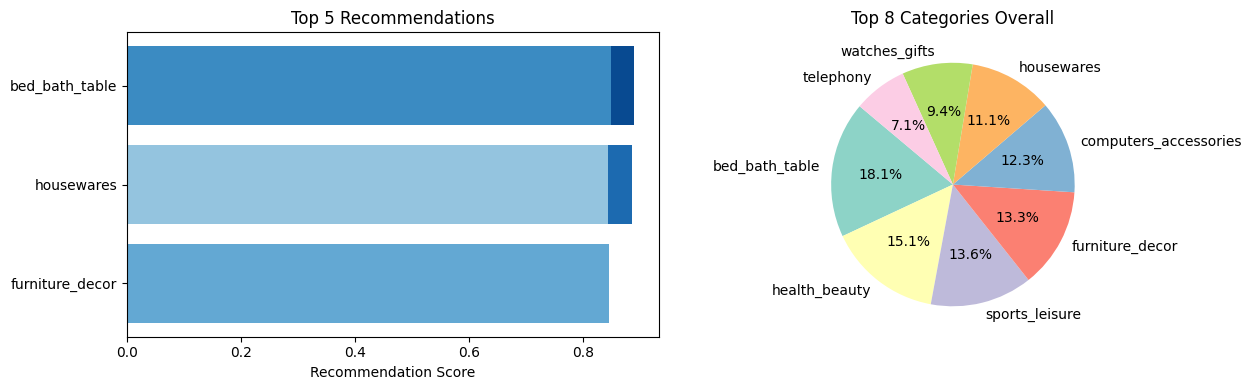

In [10]:
# Visualise

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recommendations)))
axes[0].barh(recommendations['product_category_name_english'],
             recommendations['score'], color=bar_colors[::-1])
axes[0].set_xlabel('Recommendation Score')
axes[0].set_title('Top 5 Recommendations')
axes[0].invert_yaxis()

cat_dist = master_df['product_category_name_english'].value_counts().head(8)
axes[1].pie(cat_dist.values, labels=cat_dist.index,
            autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
axes[1].set_title('Top 8 Categories Overall')

plt.tight_layout()
plt.show()

---
# MODEL 3 — Brazilian Review Sentiment (HuggingFace Multilingual)

**Model used:** `lxyuan/distilbert-base-multilingual-cased-sentiments-student`

- Supports 7 languages including **Portuguese** natively
- Outputs: **positive / neutral / negative** directly
- No training needed — just load and predict
- Much smaller and faster than full XLM-RoBERTa

In [1]:
!pip install transformers

In [2]:
# Load multilingual sentiment model

from transformers import pipeline

sentiment_pipe = pipeline(
    task  = 'text-classification',
    model = 'lxyuan/distilbert-base-multilingual-cased-sentiments-student',
    top_k = None   # returns scores for all 3 labels
)

print('Multilingual sentiment model loaded ')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Multilingual sentiment model loaded 


In [11]:
# Prepare review data

review_df = master_df[['review_comment_message', 'review_score']].dropna(subset=['review_comment_message']).copy()
review_df = review_df[review_df['review_comment_message'].str.len() > 10]
review_df = review_df.reset_index(drop=True)

print('Reviews available:', len(review_df))
review_df

Reviews available: 46148


,review_comment_message,review_score
0,"Não testei o produto ainda, mas ele veio corre...",4.0
1,"Não testei o produto ainda, mas ele veio corre...",4.0
2,"Não testei o produto ainda, mas ele veio corre...",4.0
3,Muito bom o produto.,4.0
4,O produto foi exatamente o que eu esperava e e...,5.0
...,...,...
46143,"Ele não é um mini cajon, é um shaker, ou seja,...",1.0
46144,So uma peça que veio rachado mas tudo bem rs,4.0
46145,Foi entregue antes do prazo.,5.0
46146,Foi entregue somente 1. Quero saber do outro p...,2.0


In [12]:
# Test the model on a few Portuguese reviews first

test_reviews = [
    'Produto chegou rápido e em perfeito estado! Adorei, recomendo muito!',
    'O produto é ok, mas a entrega demorou mais do que o esperado.',
    'Péssimo! Produto veio danificado e o vendedor não respondeu minha reclamação.',
    'Boa qualidade pelo preço. Entrega dentro do prazo.'
]

print('Testing on Portuguese reviews:\n')
for review in test_reviews:
    output = sentiment_pipe(review)[0]
    top    = max(output, key=lambda x: x['score'])
    label  = top['label']
    score  = round(top['score'], 3)
    emoji  = {'positive': '✅', 'neutral': '⚠️', 'negative': '❌'}[label]
    print(f'{emoji}  {label.upper():8s}  ({score})  →  "{review[:65]}"')

Testing on Portuguese reviews:

✅  POSITIVE  (0.75)  →  "Produto chegou rápido e em perfeito estado! Adorei, recomendo mui"
✅  POSITIVE  (0.885)  →  "O produto é ok, mas a entrega demorou mais do que o esperado."
❌  NEGATIVE  (0.87)  →  "Péssimo! Produto veio danificado e o vendedor não respondeu minha"
✅  POSITIVE  (0.958)  →  "Boa qualidade pelo preço. Entrega dentro do prazo."


In [13]:
# Run on a sample of 1000 reviews from the dataset
# (full dataset = 118k rows, use a sample for speed)

sample_reviews = review_df.sample(1000, random_state=42).reset_index(drop=True)

# Truncate text to 512 chars (model max input)
texts = sample_reviews['review_comment_message'].str[:512].tolist()

# Run batch prediction
outputs = sentiment_pipe(texts, batch_size=32)

# Extract top label and confidence for each review
sample_reviews['predicted_label']      = [max(o, key=lambda x: x['score'])['label']  for o in outputs]
sample_reviews['predicted_confidence'] = [round(max(o, key=lambda x: x['score'])['score'], 3) for o in outputs]

print('Predictions done ✅')
sample_reviews[['review_comment_message', 'review_score', 'predicted_label', 'predicted_confidence']].head(8)

Predictions done ✅


,review_comment_message,review_score,predicted_label,predicted_confidence
0,Adorei comprar cm vcs.recomendo.,5.0,positive,0.565
1,"Super satisfeita com a compra feita, a entrega...",5.0,positive,0.895
2,Tive problema com o produto e já abri uma recl...,3.0,negative,0.709
3,O termômetro veio com a pilha vazando e não li...,1.0,negative,0.579
4,"Eu recebi 1 taça de cada, eu comprei 6 de cada...",1.0,positive,0.470
5,chegou muito antes do prazo. em menos de uma s...,5.0,negative,0.473
6,"Linda garrafa, material de qualidade... Entreg...",5.0,positive,0.866
7,Obrigada pela atenção vcs foram corretos estou...,5.0,negative,0.657


In [14]:
# How well does the model agree with review_score?
# Map review_score to expected sentiment

def score_to_label(score):
    if score >= 4: return 'positive'
    if score == 3: return 'neutral'
    return 'negative'

sample_reviews['expected_label'] = sample_reviews['review_score'].apply(score_to_label)

match = (sample_reviews['predicted_label'] == sample_reviews['expected_label']).mean()
print(f'Agreement with review score: {match:.1%}')

print('\nPrediction counts:')
print(sample_reviews['predicted_label'].value_counts())

Agreement with review score: 66.0%

Prediction counts:
predicted_label
positive    569
negative    355
neutral      76
Name: count, dtype: int64


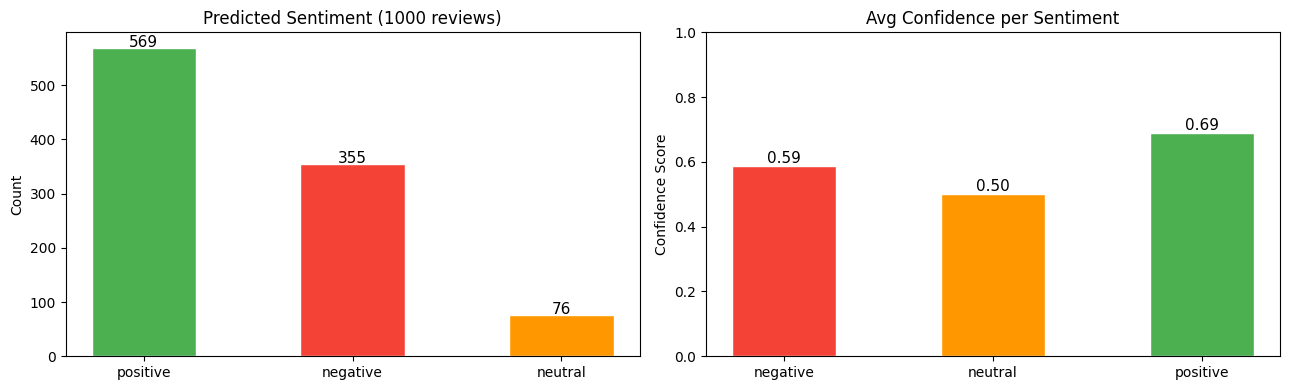

In [19]:
# Visualise results

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Predicted sentiment distribution
counts = sample_reviews['predicted_label'].value_counts()
bar_colors = [{'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336'}[c] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Predicted Sentiment (1000 reviews)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Average confidence per label
avg_conf = sample_reviews.groupby('predicted_label')['predicted_confidence'].mean()
conf_colors = [{'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336'}[c] for c in avg_conf.index]
axes[1].bar(avg_conf.index, avg_conf.values, color=conf_colors, edgecolor='white', width=0.5)
axes[1].set_title('Avg Confidence per Sentiment')
axes[1].set_ylabel('Confidence Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(avg_conf.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

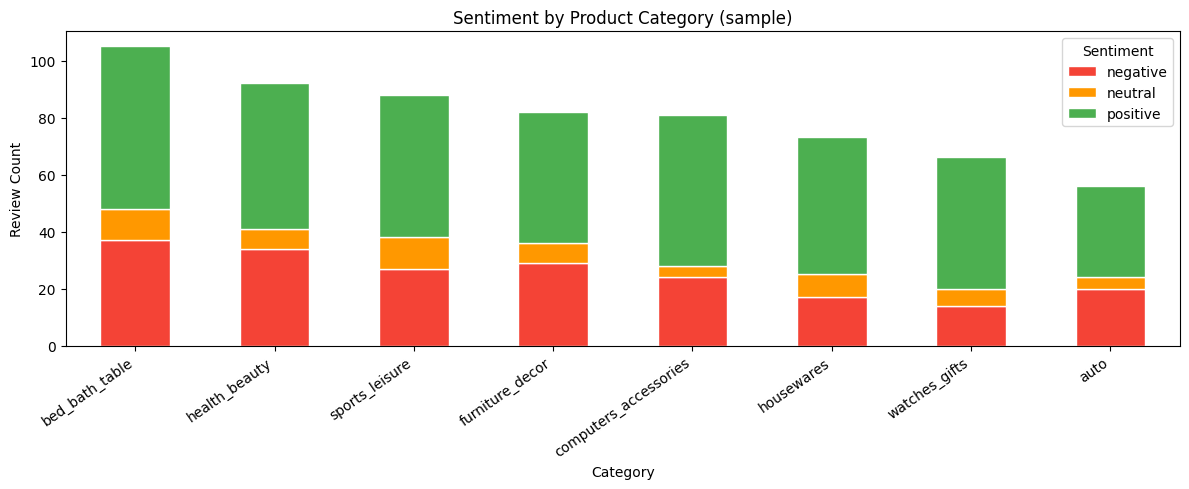

In [21]:
# Sentiment breakdown by product category

merged = sample_reviews.merge(
    master_df[['review_comment_message', 'product_category_name_english']].drop_duplicates(),
    on='review_comment_message', how='left'
)

breakdown = (
    merged.groupby(['product_category_name_english', 'predicted_label'])
    .size().unstack(fill_value=0)
)
breakdown['total'] = breakdown.sum(axis=1)
top8 = breakdown.nlargest(8, 'total').drop('total', axis=1)

color_map = [{'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336'}.get(c, 'gray')
             for c in top8.columns]

top8.plot(kind='bar', stacked=True, figsize=(12, 5), color=color_map, edgecolor='white')
plt.title('Sentiment by Product Category (sample)')
plt.xlabel('Category')
plt.ylabel('Review Count')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [23]:
# Predict on any new text — one line!

def predict_sentiment(text):
    output = sentiment_pipe(text[:512])[0]
    top    = max(output, key=lambda x: x['score'])
    print(f"{top['label'].upper()}  (confidence: {top['score']:.3f})")
    print(f'   "{text[:80]}"')


predict_sentiment('Muito bom! Entrega rápida e produto de ótima qualidade.')
predict_sentiment('O produto não funcionou e o suporte não me ajudou.')
predict_sentiment('Normal, nada de especial.')

POSITIVE  (confidence: 0.990)
   "Muito bom! Entrega rápida e produto de ótima qualidade."
NEGATIVE  (confidence: 0.550)
   "O produto não funcionou e o suporte não me ajudou."
NEUTRAL  (confidence: 0.721)
   "Normal, nada de especial."
